# AI-Powered Customer Feedback Intelligence & Decision Analytics

This project transforms unstructured e-commerce customer reviews into structured customer intelligence using Python and LLM-assisted classification.

The analysis combines traditional customer feedback analytics with AI-generated sentiment, issue category, intent, urgency, and recommended actions to identify recurring customer concerns and support business decision-making.

## 1. Dataset Loading & Initial Inspection

The analysis uses the Women's E-Commerce Clothing Reviews dataset, containing customer review text, star ratings, recommendation indicators, product categories, and customer metadata.

This section loads the raw dataset and performs an initial inspection of its dimensions, columns, and sample records before cleaning.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (23486, 11)

Columns:
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## 2. Data Cleaning & Quality Audit

Before analysis, the dataset was audited for duplicate records, missing review text, cancellations, and other data-quality issues.

Reviews without usable text were excluded from text analysis, while the original rating and recommendation indicators were retained for validation and comparison.

The cleaned dataset contains **22,641 usable customer reviews**, which serves as the basis for the full-dataset descriptive analysis.

In [6]:
# Data quality audit

print("Total records:", len(df))
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nRating distribution:")
print(df["Rating"].value_counts().sort_index())

print("\nRecommendation distribution:")
print(df["Recommended IND"].value_counts())

print("\nDepartment distribution:")
print(df["Department Name"].value_counts(dropna=False))

Total records: 23486
Duplicate rows: 0

Missing values:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Rating distribution:
Rating
1      842
2     1565
3     2871
4     5077
5    13131
Name: count, dtype: int64

Recommendation distribution:
Recommended IND
1    19314
0     4172
Name: count, dtype: int64

Department distribution:
Department Name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
NaN            14
Name: count, dtype: int64


In [7]:
# Prepare review-level analysis dataset

reviews = df.drop(columns=["Unnamed: 0"]).copy()

# Reviews without text cannot be used for text analysis
reviews = reviews.dropna(subset=["Review Text"]).copy()

reviews["Review Text"] = reviews["Review Text"].str.strip()

# Remove empty review strings if any
reviews = reviews[reviews["Review Text"] != ""].copy()

print("Original records:", len(df))
print("Reviews with usable text:", len(reviews))
print("Records excluded from text analysis:", len(df) - len(reviews))

reviews.head()

Original records: 23486
Reviews with usable text: 22641
Records excluded from text analysis: 845


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## 3. Baseline Customer Feedback Analytics

Before applying LLM-based classification, the cleaned review dataset was analyzed using traditional descriptive analytics to establish the overall customer feedback baseline.

Key metrics include review volume, average star rating, recommendation rate, low-rating review volume, rating distribution, and department-level performance. These full-dataset metrics provide context for interpreting the subsequent AI-enriched analysis.

In [8]:
# Baseline customer feedback analytics

total_reviews = len(reviews)
avg_rating = reviews["Rating"].mean()
recommend_rate = reviews["Recommended IND"].mean() * 100

negative_reviews = reviews[reviews["Rating"] <= 2]
negative_rate = len(negative_reviews) / total_reviews * 100

print(f"Usable Reviews: {total_reviews:,}")
print(f"Average Rating: {avg_rating:.2f} / 5")
print(f"Recommendation Rate: {recommend_rate:.1f}%")
print(f"Low-Rating Reviews (1-2 stars): {len(negative_reviews):,}")
print(f"Low-Rating Rate: {negative_rate:.1f}%")

print("\n--- Rating Distribution ---")
print(reviews["Rating"].value_counts().sort_index())

print("\n--- Reviews by Department ---")
print(reviews["Department Name"].value_counts())

print("\n--- Average Rating by Department ---")
print(
    reviews.groupby("Department Name")["Rating"]
    .agg(["count", "mean"])
    .sort_values("mean")
    .round(2)
)

Usable Reviews: 22,641
Average Rating: 4.18 / 5
Recommendation Rate: 81.9%
Low-Rating Reviews (1-2 stars): 2,370
Low-Rating Rate: 10.5%

--- Rating Distribution ---
Rating
1      821
2     1549
3     2823
4     4908
5    12540
Name: count, dtype: int64

--- Reviews by Department ---
Department Name
Tops        10048
Dresses      6145
Bottoms      3662
Intimate     1653
Jackets      1002
Trend         118
Name: count, dtype: int64

--- Average Rating by Department ---
                 count  mean
Department Name             
Trend              118  3.84
Dresses           6145  4.14
Tops             10048  4.16
Jackets           1002  4.25
Intimate          1653  4.27
Bottoms           3662  4.28


In [9]:
# Identify departments with the largest volume of low-rated feedback

department_feedback = (
    reviews.groupby("Department Name")
    .agg(
        Reviews=("Rating", "size"),
        Average_Rating=("Rating", "mean"),
        Low_Rating_Reviews=("Rating", lambda x: (x <= 2).sum()),
        Recommendation_Rate=("Recommended IND", "mean")
    )
    .reset_index()
)

department_feedback["Low_Rating_Rate"] = (
    department_feedback["Low_Rating_Reviews"]
    / department_feedback["Reviews"] * 100
)

department_feedback["Recommendation_Rate"] *= 100

department_feedback = department_feedback.sort_values(
    "Low_Rating_Reviews",
    ascending=False
)

department_feedback.round(2)


,Department Name,Reviews,Average_Rating,Low_Rating_Reviews,Recommendation_Rate,Low_Rating_Rate
4,Tops,10048,4.16,1096,81.07,10.91
1,Dresses,6145,4.14,681,80.52,11.08
0,Bottoms,3662,4.28,317,84.95,8.66
2,Intimate,1653,4.27,147,84.63,8.89
3,Jackets,1002,4.25,108,83.33,10.78
5,Trend,118,3.84,21,74.58,17.80


## 4. Stratified Sampling for LLM Enrichment

To make LLM-based review enrichment computationally efficient while preserving representation across customer satisfaction levels, a stratified sample of **500 reviews** was created from the cleaned dataset.

The sample contains **100 reviews from each star rating (1–5)** using a fixed random seed for reproducibility. This design intentionally over-represents lower ratings relative to the full dataset, allowing the analysis to capture both positive and negative feedback patterns.

Because the sample is stratified by rating, percentages derived from the LLM-enriched sample should be interpreted as **sample-level analytical results rather than population prevalence estimates**.

In [10]:
# Create a stratified sample for LLM enrichment

sample_size_per_rating = 100

ai_sample = (
    reviews.groupby("Rating", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(sample_size_per_rating, len(x)),
            random_state=42
        )
    )
    .reset_index(drop=True)
)

print("LLM analysis sample:", len(ai_sample))

print("\nRating distribution:")
print(ai_sample["Rating"].value_counts().sort_index())

print("\nRecommendation distribution:")
print(ai_sample["Recommended IND"].value_counts())

ai_sample[
    ["Review Text", "Rating", "Recommended IND", "Department Name"]
].head(10)

LLM analysis sample: 500

Rating distribution:
Rating
1    100
2    100
3    100
4    100
5    100
Name: count, dtype: int64

Recommendation distribution:
Recommended IND
0    258
1    242
Name: count, dtype: int64


/tmp/ipykernel_195/1182243293.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Review Text,Rating,Recommended IND,Department Name
0,"If you have any curves, avoid! it is not flatt...",1,0,Dresses
1,I've purchased pilcro jeans in the past and th...,1,0,Bottoms
2,"I bought this top and it ran huge, i had to ge...",1,0,Tops
3,Too tight in strange ways. beautiful dress i w...,1,0,Dresses
4,I am floored by all of the positive comments a...,1,0,Bottoms
5,I was so looking forward to an awesome maxi dr...,1,0,Dresses
6,"I went with my usual size, but it is too tight...",1,0,Dresses
7,This pants the worst short that i ever had!!\r...,1,0,Bottoms
8,I bought a pair of these a month ago and first...,1,0,Bottoms
9,Agree with previous reviewer. i am usually an ...,1,0,Dresses


In [11]:
try:
    import openai
    print("OpenAI package installed.")
    print("Version:", openai.__version__)
except ImportError:
    print("OpenAI package is NOT installed.")

OpenAI package installed.
Version: 3.24.0


In [12]:
%pip install -q openai

Note: you may need to restart the kernel to use updated packages.


In [13]:
import openai
print("OpenAI package installed.")
print("Version:", openai.__version__)

OpenAI package installed.
Version: 3.24.0


In [ ]:
import os
import getpass
from openai import OpenAI

os.environ["OPENAI_API_KEY"] = getpass.getpass(
    "Paste your OpenAI API key here: "
)

client = OpenAI()

print("OpenAI client initialized successfully.")

## 5. LLM-Based Structured Customer Feedback Enrichment

To transform unstructured review text into analysis-ready customer intelligence, the sampled reviews were enriched using the OpenAI API with structured outputs validated through Pydantic.

Each review was classified across five business-oriented dimensions:

- **Sentiment:** Positive, Neutral, or Negative
- **Issue Category:** Fit & Sizing, Product Quality, Style & Design, Comfort, Price & Value, or Other
- **Customer Intent:** Praise, Complaint, Return, Recommendation, or General Feedback
- **Urgency:** Low, Medium, or High
- **Recommended Action:** A concise business action derived from the review

A predefined schema and controlled category taxonomy were used to keep model outputs consistent and suitable for downstream analysis.

In [15]:
from pydantic import BaseModel
from typing import Literal

class CustomerFeedback(BaseModel):
    sentiment: Literal["Positive", "Neutral", "Negative"]
    issue_category: Literal[
        "Fit & Sizing",
        "Product Quality",
        "Style & Design",
        "Comfort",
        "Price & Value",
        "Other"
    ]
    intent: Literal[
        "Praise",
        "Complaint",
        "Return",
        "Recommendation",
        "General Feedback"
    ]
    urgency: Literal["Low", "Medium", "High"]
    recommended_action: str

In [16]:
def classify_review(review_text):
    response = client.responses.parse(
        model="gpt-5-mini",
        input=[
            {
                "role": "system",
                "content": """
You are a customer feedback analyst for an e-commerce clothing retailer.

Analyze each customer review and return structured customer intelligence.

Classification guidelines:

Sentiment:
- Positive: primarily satisfied or favorable
- Neutral: mixed or informational without clear positive/negative dominance
- Negative: primarily dissatisfied

Issue category:
- Fit & Sizing: size, fit, length, tightness, looseness
- Product Quality: material, construction, durability, defects
- Style & Design: appearance, color, cut, design
- Comfort: comfort, feel, wearability
- Price & Value: price, value for money
- Other: feedback not captured above

Intent:
- Praise: primarily expressing satisfaction
- Complaint: primarily expressing dissatisfaction
- Return: explicitly mentions returning/exchanging
- Recommendation: explicitly recommends or discourages purchase
- General Feedback: none of the above clearly dominates

Urgency:
- High: serious defect, safety concern, or severe product failure
- Medium: meaningful issue requiring business attention
- Low: praise, minor concern, or general feedback

Recommended action:
Provide one short, specific business action appropriate to the review.
"""
            },
            {
                "role": "user",
                "content": review_text
            }
        ],
        text_format=CustomerFeedback
    )

    return response.output_parsed, response.usage

In [25]:
import pandas as pd
import time
import os

CHECKPOINT_FILE = "ai_feedback_checkpoint.csv"
SAVE_EVERY = 10

# Load successful results
results_df = pd.read_csv(CHECKPOINT_FILE)
results = results_df.to_dict("records")
completed_indices = set(results_df["sample_index"].astype(int))

print(f"Loaded checkpoint: {len(results)} successful reviews.")
print(f"Remaining: {len(ai_sample) - len(completed_indices)} reviews.")

rate_limit_hit = False

for i in range(len(ai_sample)):

    if i in completed_indices:
        continue

    row = ai_sample.loc[i]
    review_text = row["Review Text"]

    try:
        result, usage = classify_review(review_text)

        results.append({
            "sample_index": i,
            "rating": row["Rating"],
            "recommended_ind": row["Recommended IND"],
            "department": row["Department Name"],
            "review_text": review_text,
            "sentiment": result.sentiment,
            "issue_category": result.issue_category,
            "intent": result.intent,
            "urgency": result.urgency,
            "recommended_action": result.recommended_action,
            "input_tokens": usage.input_tokens,
            "output_tokens": usage.output_tokens,
            "total_tokens": usage.total_tokens
        })

        completed_indices.add(i)

        # Save every 10 new successful results
        if len(results) % SAVE_EVERY == 0:
            pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)
            print(f"Saved: {len(results)}/500")

        time.sleep(0.3)

    except Exception as e:

        # Save everything completed before stopping
        pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)

        if "429" in str(e) or "rate limit" in str(e).lower():
            print("\nRATE LIMIT REACHED.")
            print(f"Results safely saved: {len(results)}/500")
            print("Stop here and resume after the API limit resets.")
            rate_limit_hit = True
            break

        else:
            print(f"\nError on review {i}: {type(e).__name__}: {e}")
            print("Results saved. Stopping so the error can be inspected.")
            break

# Final save
ai_results = pd.DataFrame(results)
ai_results.to_csv(CHECKPOINT_FILE, index=False)

print(f"\nCurrent total successfully classified: {len(ai_results)}/500")

Loaded checkpoint: 225 successful reviews.
Remaining: 275 reviews.
Saved: 230/500
Saved: 240/500
Saved: 250/500
Saved: 260/500
Saved: 270/500
Saved: 280/500
Saved: 290/500
Saved: 300/500
Saved: 310/500
Saved: 320/500
Saved: 330/500
Saved: 340/500
Saved: 350/500
Saved: 360/500
Saved: 370/500
Saved: 380/500
Saved: 390/500
Saved: 400/500
Saved: 410/500
Saved: 420/500
Saved: 430/500
Saved: 440/500
Saved: 450/500
Saved: 460/500
Saved: 470/500
Saved: 480/500
Saved: 490/500
Saved: 500/500

Current total successfully classified: 500/500


In [26]:
# ==========================================
# AI Results — Quality Assurance
# ==========================================

# Sort results back into original sample order
ai_results = ai_results.sort_values("sample_index").reset_index(drop=True)

print("=== DATA INTEGRITY ===")
print("Shape:", ai_results.shape)
print("Unique sample indices:", ai_results["sample_index"].nunique())
print("Duplicate sample indices:", ai_results["sample_index"].duplicated().sum())

print("\n=== MISSING VALUES ===")
print(
    ai_results[
        ["sentiment", "issue_category", "intent",
         "urgency", "recommended_action"]
    ].isna().sum()
)

print("\n=== SENTIMENT ===")
print(ai_results["sentiment"].value_counts())

print("\n=== ISSUE CATEGORY ===")
print(ai_results["issue_category"].value_counts())

print("\n=== INTENT ===")
print(ai_results["intent"].value_counts())

print("\n=== URGENCY ===")
print(ai_results["urgency"].value_counts())

print("\n=== TOKEN USAGE ===")
print(
    ai_results[
        ["input_tokens", "output_tokens", "total_tokens"]
    ].sum()
)

=== DATA INTEGRITY ===
Shape: (500, 13)
Unique sample indices: 500
Duplicate sample indices: 0

=== MISSING VALUES ===
sentiment             0
issue_category        0
intent                0
urgency               0
recommended_action    0
dtype: int64

=== SENTIMENT ===
sentiment
Negative    283
Positive    163
Neutral      54
Name: count, dtype: int64

=== ISSUE CATEGORY ===
issue_category
Fit & Sizing       281
Product Quality    109
Style & Design      90
Comfort             13
Price & Value        7
Name: count, dtype: int64

=== INTENT ===
intent
Complaint           207
Praise              156
Return              113
General Feedback     16
Recommendation        8
Name: count, dtype: int64

=== URGENCY ===
urgency
Medium    310
Low       188
High        2
Name: count, dtype: int64

=== TOKEN USAGE ===
input_tokens     226114
output_tokens    223595
total_tokens     449709
dtype: int64


In [27]:
print("=== SENTIMENT BY STAR RATING ===")

sentiment_by_rating = pd.crosstab(
    ai_results["rating"],
    ai_results["sentiment"],
    margins=True
)

display(sentiment_by_rating)


print("\n=== ISSUE CATEGORY BY STAR RATING ===")

issue_by_rating = pd.crosstab(
    ai_results["rating"],
    ai_results["issue_category"]
)

display(issue_by_rating)


print("\n=== SENTIMENT BY RECOMMENDATION ===")

sentiment_by_recommendation = pd.crosstab(
    ai_results["recommended_ind"],
    ai_results["sentiment"],
    normalize="index"
).round(3) * 100

display(sentiment_by_recommendation)

=== SENTIMENT BY STAR RATING ===


sentiment,Negative,Neutral,Positive,All
rating,,,,
1,97,1,2,100
2,96,4,0,100
3,72,25,3,100
4,17,22,61,100
5,1,2,97,100
All,283,54,163,500



=== ISSUE CATEGORY BY STAR RATING ===


issue_category,Comfort,Fit & Sizing,Price & Value,Product Quality,Style & Design
rating,,,,,
1,0,46,1,39,14
2,1,63,1,23,12
3,2,65,2,19,12
4,2,60,3,16,19
5,8,47,0,12,33



=== SENTIMENT BY RECOMMENDATION ===


sentiment,Negative,Neutral,Positive
recommended_ind,,,
0,93.8,5.8,0.4
1,16.9,16.1,66.9


In [28]:
# ==========================================
# BUSINESS DRIVER ANALYSIS
# ==========================================

print("=== ISSUE × SENTIMENT ===")

issue_sentiment = pd.crosstab(
    ai_results["issue_category"],
    ai_results["sentiment"]
)

issue_sentiment["Total"] = issue_sentiment.sum(axis=1)

issue_sentiment["Negative_Rate_%"] = (
    issue_sentiment["Negative"] /
    issue_sentiment["Total"] * 100
).round(1)

display(
    issue_sentiment.sort_values(
        "Negative_Rate_%",
        ascending=False
    )
)


print("\n=== ISSUE × INTENT ===")

issue_intent = pd.crosstab(
    ai_results["issue_category"],
    ai_results["intent"]
)

issue_intent["Total"] = issue_intent.sum(axis=1)

display(issue_intent)


print("\n=== NEGATIVE REVIEWS — ISSUE DRIVERS ===")

negative_issues = (
    ai_results.loc[
        ai_results["sentiment"] == "Negative",
        "issue_category"
    ]
    .value_counts()
)

negative_issue_share = (
    negative_issues /
    negative_issues.sum() * 100
).round(1)

negative_summary = pd.DataFrame({
    "Negative Reviews": negative_issues,
    "Share of Negative Reviews (%)": negative_issue_share
})

display(negative_summary)


print("\n=== RETURN INTENT — ISSUE DRIVERS ===")

return_issues = (
    ai_results.loc[
        ai_results["intent"] == "Return",
        "issue_category"
    ]
    .value_counts()
)

return_issue_share = (
    return_issues /
    return_issues.sum() * 100
).round(1)

return_summary = pd.DataFrame({
    "Return Reviews": return_issues,
    "Share of Return Intent (%)": return_issue_share
})

display(return_summary)

=== ISSUE × SENTIMENT ===


sentiment,Negative,Neutral,Positive,Total,Negative_Rate_%
issue_category,,,,,
Product Quality,77,8,24,109,70.6
Fit & Sizing,166,39,76,281,59.1
Price & Value,4,1,2,7,57.1
Style & Design,33,6,51,90,36.7
Comfort,3,0,10,13,23.1



=== ISSUE × INTENT ===


intent,Complaint,General Feedback,Praise,Recommendation,Return,Total
issue_category,,,,,,
Comfort,3,0,9,1,0,13
Fit & Sizing,130,12,71,4,64,281
Price & Value,2,0,2,0,3,7
Product Quality,51,2,24,1,31,109
Style & Design,21,2,50,2,15,90



=== NEGATIVE REVIEWS — ISSUE DRIVERS ===


,Negative Reviews,Share of Negative Reviews (%)
issue_category,,
Fit & Sizing,166,58.7
Product Quality,77,27.2
Style & Design,33,11.7
Price & Value,4,1.4
Comfort,3,1.1



=== RETURN INTENT — ISSUE DRIVERS ===


,Return Reviews,Share of Return Intent (%)
issue_category,,
Fit & Sizing,64,56.6
Product Quality,31,27.4
Style & Design,15,13.3
Price & Value,3,2.7


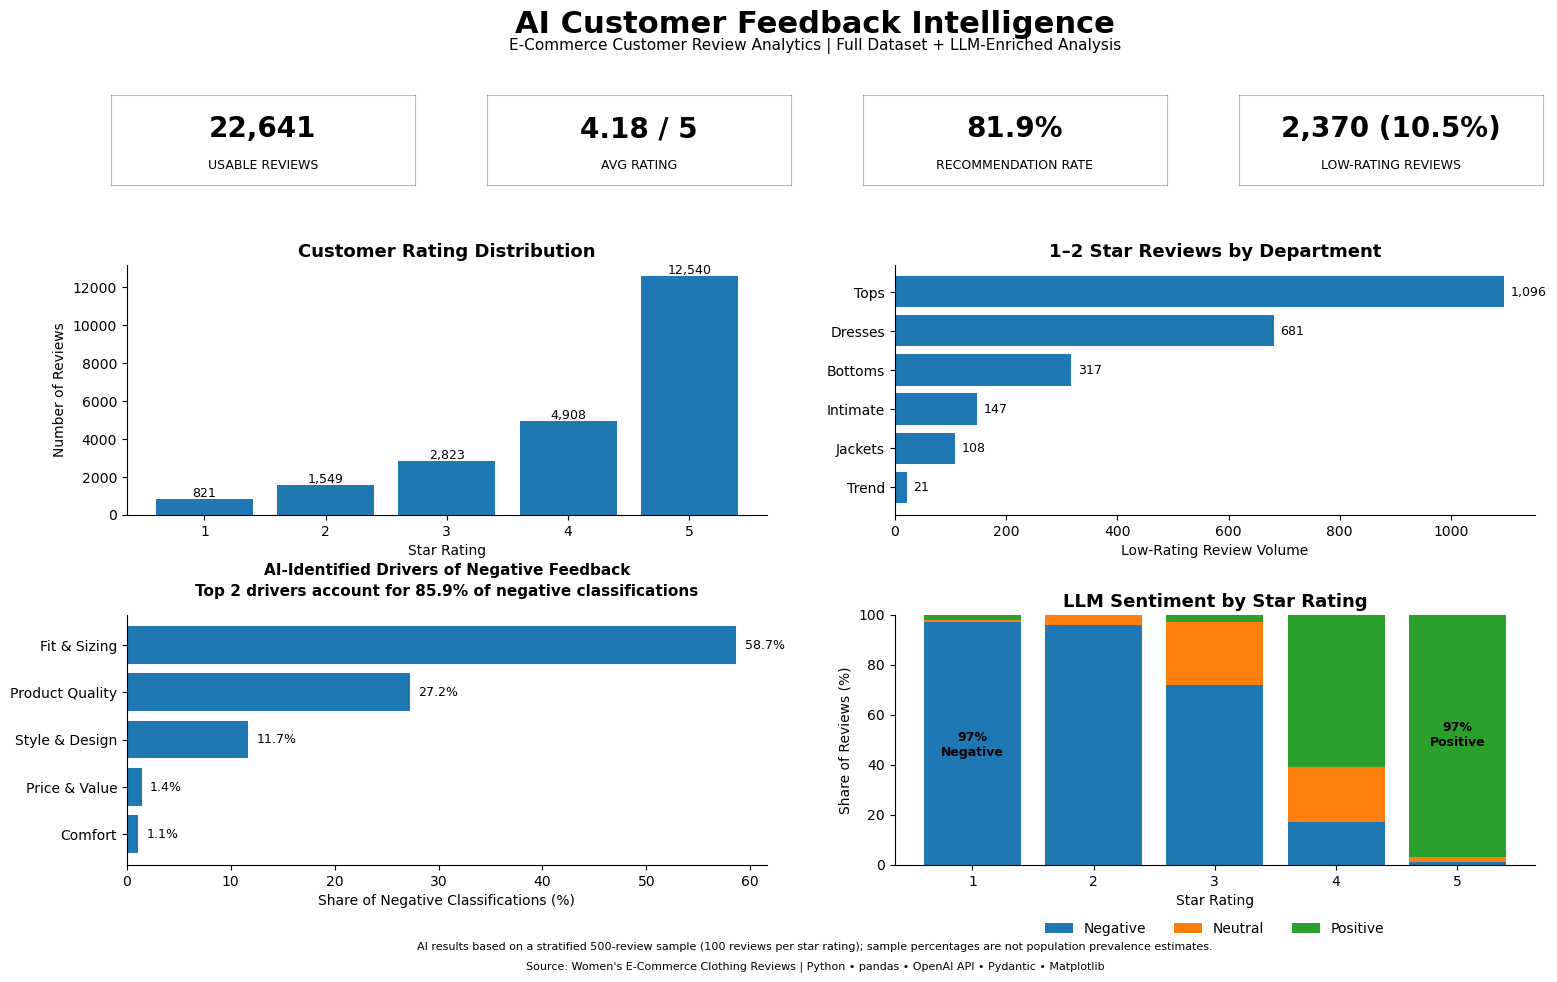

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================
# AI CUSTOMER FEEDBACK INTELLIGENCE — FINAL DASHBOARD
# =========================================================

# ---------- Full-dataset metrics ----------

total_reviews = len(reviews)
avg_rating = reviews["Rating"].mean()
recommend_rate = reviews["Recommended IND"].mean() * 100

low_rating = reviews[reviews["Rating"].isin([1, 2])]
low_rating_count = len(low_rating)
low_rating_rate = low_rating_count / total_reviews * 100

rating_counts = reviews["Rating"].value_counts().sort_index()

department_low = (
    low_rating["Department Name"]
    .value_counts()
    .sort_values()
)

# ---------- AI results ----------

negative_results = ai_results[
    ai_results["sentiment"] == "Negative"
]

negative_driver = (
    negative_results["issue_category"]
    .value_counts()
)

negative_driver_pct = (
    negative_driver / len(negative_results) * 100
).sort_values()

# Sentiment × rating percentages
sentiment_rating = pd.crosstab(
    ai_results["rating"],
    ai_results["sentiment"],
    normalize="index"
) * 100

for col in ["Negative", "Neutral", "Positive"]:
    if col not in sentiment_rating.columns:
        sentiment_rating[col] = 0

sentiment_rating = sentiment_rating[
    ["Negative", "Neutral", "Positive"]
]


# =========================================================
# CANVAS
# =========================================================

fig = plt.figure(figsize=(16, 10))

fig.suptitle(
    "AI Customer Feedback Intelligence",
    fontsize=22,
    fontweight="bold",
    y=0.975
)

fig.text(
    0.5,
    0.935,
    "E-Commerce Customer Review Analytics | Full Dataset + LLM-Enriched Analysis",
    ha="center",
    fontsize=11
)


# =========================================================
# KPI CARDS
# =========================================================

kpis = [
    ("USABLE REVIEWS", f"{total_reviews:,}"),
    ("AVG RATING", f"{avg_rating:.2f} / 5"),
    ("RECOMMENDATION RATE", f"{recommend_rate:.1f}%"),
    ("LOW-RATING REVIEWS", f"{low_rating_count:,} ({low_rating_rate:.1f}%)")
]

positions = [0.06, 0.295, 0.53, 0.765]

for x, (label, value) in zip(positions, kpis):

    ax = fig.add_axes([x, 0.80, 0.19, 0.09])

    ax.text(
        0.5, 0.62,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.22,
        label,
        ha="center",
        va="center",
        fontsize=9
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_alpha(0.25)


# =========================================================
# CHART 1 — RATING DISTRIBUTION
# =========================================================

ax1 = fig.add_axes([0.07, 0.47, 0.40, 0.25])

bars = ax1.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

ax1.set_title(
    "Customer Rating Distribution",
    fontsize=13,
    fontweight="bold"
)

ax1.set_xlabel("Star Rating")
ax1.set_ylabel("Number of Reviews")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

for bar, value in zip(bars, rating_counts.values):

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        value + 150,
        f"{value:,}",
        ha="center",
        fontsize=9
    )


# =========================================================
# CHART 2 — LOW-RATING VOLUME BY DEPARTMENT
# =========================================================

ax2 = fig.add_axes([0.55, 0.47, 0.40, 0.25])

bars2 = ax2.barh(
    department_low.index,
    department_low.values
)

ax2.set_title(
    "1–2 Star Reviews by Department",
    fontsize=13,
    fontweight="bold"
)

ax2.set_xlabel("Low-Rating Review Volume")

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

for bar, value in zip(bars2, department_low.values):

    ax2.text(
        value + 12,
        bar.get_y() + bar.get_height()/2,
        f"{value:,}",
        va="center",
        fontsize=9
    )


# =========================================================
# CHART 3 — NEGATIVE FEEDBACK DRIVERS
# =========================================================

ax3 = fig.add_axes([0.07, 0.12, 0.40, 0.25])

bars3 = ax3.barh(
    negative_driver_pct.index,
    negative_driver_pct.values
)


ax3.set_title(
    "AI-Identified Drivers of Negative Feedback\n"
    "Top 2 drivers account for 85.9% of negative classifications",
    fontsize=11,
    fontweight="bold",
    pad=14,
    linespacing=1.5
)

ax3.set_xlabel("Share of Negative Classifications (%)")

ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

for bar, value in zip(bars3, negative_driver_pct.values):

    ax3.text(
        value + 0.8,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )
    

# =========================================================
# CHART 4 — SENTIMENT BY STAR RATING
# =========================================================

ax4 = fig.add_axes([0.55, 0.12, 0.40, 0.25])

ratings = sentiment_rating.index

negative = sentiment_rating["Negative"]
neutral = sentiment_rating["Neutral"]
positive = sentiment_rating["Positive"]

ax4.bar(
    ratings,
    negative,
    label="Negative"
)

ax4.bar(
    ratings,
    neutral,
    bottom=negative,
    label="Neutral"
)

ax4.bar(
    ratings,
    positive,
    bottom=negative + neutral,
    label="Positive"
)

ax4.set_title(
    "LLM Sentiment by Star Rating",
    fontsize=13,
    fontweight="bold"
)

ax4.set_xlabel("Star Rating")
ax4.set_ylabel("Share of Reviews (%)")
ax4.set_ylim(0, 100)
ax4.set_xticks(ratings)

ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)

ax4.text(
    1,
    48,
    "97%\nNegative",
    ha="center",
    va="center",
    fontsize=9,
    fontweight="bold"
)

ax4.text(
    5,
    52,
    "97%\nPositive",
    ha="center",
    va="center",
    fontsize=9,
    fontweight="bold"
)

ax4.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3
)


# =========================================================
# FOOTER
# =========================================================

fig.text(
    0.5,
    0.035,
    "AI results based on a stratified 500-review sample (100 reviews per star rating); "
    "sample percentages are not population prevalence estimates.",
    ha="center",
    fontsize=8
)

fig.text(
    0.5,
    0.015,
    "Source: Women's E-Commerce Clothing Reviews | "
    "Python • pandas • OpenAI API • Pydantic • Matplotlib",
    ha="center",
    fontsize=8
)

plt.savefig(
    "customer_feedback_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [37]:
import os

print(os.path.exists("customer_feedback_dashboard.png"))
print(
    round(
        os.path.getsize("customer_feedback_dashboard.png") / 1024 / 1024,
        2
    ),
    "MB"
)

True
0.53 MB


In [3]:
import pandas as pd
import os

CHECKPOINT_FILE = "ai_feedback_checkpoint.csv"

# Reload the completed 500-review AI results from checkpoint
ai_results = pd.read_csv(CHECKPOINT_FILE)

print("Loaded AI results:", ai_results.shape)

# Create a GitHub-safe derived dataset
github_results = ai_results[
    [
        "sample_index",
        "rating",
        "recommended_ind",
        "department",
        "sentiment",
        "issue_category",
        "intent",
        "urgency",
        "recommended_action"
    ]
].copy()

github_results.to_csv(
    "ai_feedback_enriched_sample.csv",
    index=False
)

print("\nGitHub dataset:", github_results.shape)
print("\nMissing values:")
print(github_results.isna().sum())
print("\nSaved: ai_feedback_enriched_sample.csv")

Loaded AI results: (500, 13)

GitHub dataset: (500, 9)

Missing values:
sample_index          0
rating                0
recommended_ind       0
department            1
sentiment             0
issue_category        0
intent                0
urgency               0
recommended_action    0
dtype: int64

Saved: ai_feedback_enriched_sample.csv


In [4]:
# Preserve the review while explicitly labeling the missing source department
github_results["department"] = github_results["department"].fillna("Unknown")

github_results.to_csv(
    "ai_feedback_enriched_sample.csv",
    index=False
)

print(github_results.isna().sum())
print("\nFinal GitHub dataset:", github_results.shape)

sample_index          0
rating                0
recommended_ind       0
department            0
sentiment             0
issue_category        0
intent                0
urgency               0
recommended_action    0
dtype: int64

Final GitHub dataset: (500, 9)
